# Set Up

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "svg"
import matplotlib.gridspec as gridspec

In [2]:
from tmd_model import *
from kubo import *

## Specify Parameters

In [3]:
cutoff = 2 #number of momentum space scattering processes allowed

In [4]:
# set twist angle
θ = 5*np.pi/180 #radians

#doping and temperature
mu = -60+4.828263103620056 #meV ~gap due to scalar potential
T = 10 #K

#heterostrain
displacement = 0
eps = 0.000
strain_dir = 0 #radians

#material parameters for MoTe2 (are given in tmd_model.py)
t_inters=[0,-8.5] #meV

In [5]:
%%time
res = 60 #runtime scales as res^2;
Nw = 201 #number of frequency steps
eta = 5j #meV
Ws = np.linspace(0.001,50,Nw)+eta*np.ones(Nw)
s = np.zeros((2, 4,4,Nw),dtype=complex)

for i in range(2): #parameter choices
    print(i)
    t_inter = t_inters[i]
    _, _, G1, G2 = geometry(θ,eps=eps,strain_dir=strain_dir)
    xs = (np.arange(res) + 0.5) / res - 0.5
    ys = (np.arange(res) + 0.5) / res - 0.5
    for x in range(0,res,1): #kx range
        for y in range(0,res,1): #ky range
            k = xs[x]*G1 + ys[y]*G2 #parallelogram BZ
            for valley in [-1,1]: #valley sum
                s[i] += kubo_fast(k,θ,mu,T,Ws,cutoff,valley=valley,t_inter=t_inter,eps=eps,strain_dir=strain_dir,displacement=displacement)
    A_BZ = np.abs(np.linalg.det(np.column_stack([G1,G2]))) #BZ area
    scale = (A_BZ/(2*np.pi)**2)/res**2 #n_pts
    s[i] *= scale

0
1
CPU times: user 24min 51s, sys: 24min 14s, total: 49min 6s
Wall time: 4min 23s


## Visualize

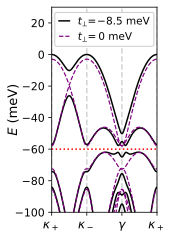

In [6]:
fig = plt.figure(figsize=(2.3,3.2), constrained_layout=True)

#band structures

res = 200

E0 = 4.828263103620056

size = 2 * (2*cutoff+1)**2

ks = np.linspace(0,1,res*3)
eigs = np.zeros((res*3,size)) #50 for cutoff = 2, 98 for cutoff = 3
k_points = np.zeros((res*3,2))

K, Kp, G1, G2 = geometry(θ,eps=eps,strain_dir=strain_dir)
G = (G1 - G2)/2 #not (0,0) !
k_points[:res]   = np.outer(K,np.ones(res)).T + np.outer(Kp-K,np.linspace(0,1,res)).T
k_points[res:2*res] = np.outer(Kp,np.ones(res)).T + np.outer(G-Kp,np.linspace(0,1,res)).T
k_points[2*res:] = np.outer(G,np.ones(res)).T+ np.outer(K-G,np.linspace(0,1,res)).T

for j in range(0,3*res,1):
    eigs[j] = np.linalg.eigvalsh(H_valley(k_points[j],θ,cutoff,t_inter=t_inters[1],valley=+1, eps=eps,strain_dir=strain_dir,displacement=displacement))
plt.plot(ks,eigs-E0,lw=1.5,c="k")
plt.plot(ks,eigs[:,0]-E0,lw=1.5,c="k",label=r"$t_{\!\perp}\!\!=\!\!-\!8.5$ meV")

for j in range(0,3*res,1):
    eigs[j] = np.linalg.eigvalsh(H_valley(k_points[j],θ,cutoff,t_inter=t_inters[0],valley=+1, eps=eps,strain_dir=strain_dir,displacement=displacement))
plt.plot(ks,eigs-E0,lw=1.2,ls="dashed",c="purple")
plt.plot(ks,eigs[:,0]-E0,lw=1.2,ls="dashed",c="purple",label=r"$t_{\!\perp}\!\!=0$ meV")


# plt.title(r"$t\!_\perp\!\!=\!$"+str(int(t_inters[i]*1000))+r"$\,$meV",fontsize=13)
plt.ylim(-100,30)
plt.ylabel(r"$E$ (meV)",fontsize=13,labelpad=-5)
for j in range(0,4,1):
  plt.axvline(j/3,ls="dashed",c="lightgray",zorder=0)
plt.xticks([0,1/3,2/3,1],[r"$\kappa_+$",r"$\kappa_-$",r"$\gamma$",r"$\kappa_+$"],fontsize=12)
plt.yticks(fontsize=11)
plt.xlim(0,1)
plt.axhline(-60,c="red",ls="dotted")
plt.legend(fontsize=10.5,loc=9,framealpha=1,handlelength=1)
plt.savefig("bands.pdf")

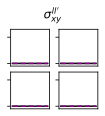

In [7]:
#layer resolved xy

fig = plt.figure(figsize=(1.35,1.5), constrained_layout=True)
gs = gridspec.GridSpec(2,2, figure=fig,
                    height_ratios=[1,1],
                    width_ratios=[1,1],
                    hspace=0.0, wspace=0.0)


plt.suptitle(r"$\sigma_{xy}^{ll'}$",fontsize=12)

Ws = np.real(Ws)

#gyrotropic response
ax = plt.subplot(gs[0,0])
plt.plot(Ws,np.real(1j*s[1, 0,1]),c="k")
plt.plot(Ws,np.real(1j*s[0, 0,1]),c="purple",ls="dashed")
plt.xticks([],[])
plt.yticks([0,1],[])
plt.ylim(-0.1,1.3)

ax = plt.subplot(gs[0,1])
plt.plot(Ws,np.real(1j*s[1, 0,3]),c="k")
plt.plot(Ws,np.real(1j*s[0, 0,3]),c="purple",ls="dashed")
plt.xticks([],[])
plt.yticks([0,1],[])
plt.ylim(-0.1,1.3)

ax = plt.subplot(gs[1,0])
plt.plot(Ws,np.real(1j*s[1, 2,1]),c="k")
plt.plot(Ws,np.real(1j*s[0, 2,1]),c="purple",ls="dashed")
plt.xticks([],[])
plt.yticks([0,1],[])
plt.ylim(-0.1,1.3)

ax = plt.subplot(gs[1,1])
plt.plot(Ws,np.real(1j*s[1, 2,3]),c="k")
plt.plot(Ws,np.real(1j*s[0, 2,3]),c="purple",ls="dashed")
plt.xticks([],[])
plt.yticks([0,1],[])
plt.ylim(-0.1,1.3)

plt.savefig("TMD-xy.pdf")

plt.show()

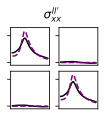

In [8]:
#layer resolved xx

fig = plt.figure(figsize=(1.35,1.5), constrained_layout=True)
gs = gridspec.GridSpec(2,2, figure=fig,
                    height_ratios=[1,1],
                    width_ratios=[1,1],
                    hspace=0.0, wspace=0.0)


Ws = np.real(Ws)


plt.suptitle(r"$\sigma_{xx}^{ll'}$",fontsize=12)

#gyrotropic response
ax = plt.subplot(gs[0,0])
plt.plot(Ws,np.real(1j*s[1, 0,0]),c="k")
plt.plot(Ws,np.real(1j*s[0, 0,0]),c="purple",ls="dashed")
plt.xticks([],[])
plt.yticks([0,1],[])
plt.ylim(-0.1,1.3)

ax = plt.subplot(gs[0,1])
plt.plot(Ws,np.real(1j*s[1, 0,2]),c="k")
plt.plot(Ws,np.real(1j*s[0, 0,2]),c="purple",ls="dashed")
plt.xticks([],[])
plt.yticks([0,1],[])
plt.ylim(-0.1,1.3)

ax = plt.subplot(gs[1,0])
plt.plot(Ws,np.real(1j*s[1, 2,0]),c="k")
plt.plot(Ws,np.real(1j*s[0, 2,0]),c="purple",ls="dashed")
plt.xticks([],[])
plt.yticks([0,1],[])
plt.ylim(-0.1,1.3)

ax = plt.subplot(gs[1,1])
plt.plot(Ws,np.real(1j*s[1, 2,2]),c="k")
plt.plot(Ws,np.real(1j*s[0, 2,2]),c="purple",ls="dashed")
plt.xticks([],[])
plt.yticks([0,1],[])
plt.ylim(-0.1,1.3)


plt.savefig("TMD-xx.pdf")
plt.show()

In [9]:
sp0 = reprocess(s[0])
sp1 = reprocess(s[1])

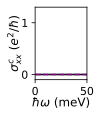

In [10]:
fig = plt.figure(figsize=(1.3,1.5), constrained_layout=True)
plt.plot(Ws,np.real(1j*sp1[0,2]),c="k")
plt.plot(Ws,np.real(1j*sp0[0,2]),c="purple",ls="dashed")
plt.xlabel(r"$\hbar\omega$ (meV)",labelpad=0,fontsize=12)
plt.ylabel(r"$\sigma_{xx}^c$ ($e^2/\hbar$)",labelpad=0,fontsize=12)
plt.xlim(0,50)
plt.ylim(-0.1,1.3)
plt.xticks(fontsize=11)
plt.yticks([0,1],fontsize=11)
plt.savefig("TMD-xxc.pdf")

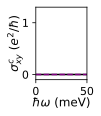

In [11]:
fig = plt.figure(figsize=(1.3,1.5), constrained_layout=True)
plt.plot(Ws,np.real(1j*sp1[0,3]),c="k")
plt.plot(Ws,np.real(1j*sp0[0,3]),c="purple",ls="dashed")
plt.xlabel(r"$\hbar\omega$ (meV)",labelpad=0,fontsize=12)
plt.ylabel(r"$\sigma_{xy}^c$ ($e^2/\hbar$)",labelpad=-1,fontsize=12)
plt.xlim(0,50)
plt.ylim(-0.1,1.3)
plt.xticks(fontsize=11)
plt.yticks([0,1],fontsize=11)
plt.savefig("TMD-xyc.pdf")